### This is the notebook for analyzing OV data

In [3]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy.sparse import csr_matrix

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import gseapy as gp
from gseapy import barplot, dotplot
from gseapy import Msigdb

import mygene
mg = mygene.MyGeneInfo()

import sys
sys.path.append("..")

from scripts.utility_functions import t_test, clean_data, read_data

cancer_type = "OV"
omic_type = "proteomics"

##### Step 1: organize the data into anndata object

In [4]:

df_transposed = read_data(cancer_type, omic_type)


In [5]:
### Make the anndata object
obs=pd.DataFrame(
    index=df_transposed.index, 
    data={
        'SampleType': df_transposed.index.str[-1],  # Last character
        'Sample': df_transposed.index.str[:-2]      # All but last two characters
    }
)

var=pd.DataFrame(
    index=df_transposed.columns, 
    data={
        "ensembl_ids_clean" : [x.split(".")[0] for x in df_transposed.columns]
    }
)

adata = ad.AnnData(
    X=df_transposed,
    obs=obs,
    var=var
)

print(adata)

AnnData object with n_obs × n_vars = 102 × 7464
    obs: 'SampleType', 'Sample'
    var: 'ensembl_ids_clean'


In [6]:
### Get gene symbol for ensembl ids (cleaned)
gene_info = mg.querymany(adata.var['ensembl_ids_clean'], scopes="ensembl.gene", fields = "symbol", species="human")
gene_symbols = {item['query']: item.get('symbol', None) for item in gene_info}

# Create a DataFrame to map Ensembl IDs to Gene Symbols
gene_mapping = pd.DataFrame(list(gene_symbols.items()), columns=['ensembl_ids_clean', 'Gene'])

# Merge with adata.var to add Gene_Symbol
adata.var = adata.var.join(gene_mapping.set_index("ensembl_ids_clean"), on='ensembl_ids_clean', how='left')

assert (adata.var.index == df_transposed.columns).all()
assert (adata.obs.index == df_transposed.index).all()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
3 input query terms found no hit:	['ENSG00000130723', 'ENSG00000148362', 'ENSG00000168078']


In [7]:
adata.var_names
adata.var
#adata.obs


,ensembl_ids_clean,Gene
idx,,
ENSG00000000003.15,ENSG00000000003,TSPAN6
ENSG00000000419.12,ENSG00000000419,DPM1
ENSG00000000938.13,ENSG00000000938,FGR
ENSG00000000971.16,ENSG00000000971,CFH
ENSG00000001036.14,ENSG00000001036,FUCA2
...,...,...
ENSG00000282651.2,ENSG00000282651,IGHV5-10-1
ENSG00000283632.3,ENSG00000283632,EXOC3L2
ENSG00000284194.3,ENSG00000284194,SCO2


In [8]:
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"

adata.write(object_file, compression="gzip")

##### Step 2: ML

In [9]:
### Main ML workflow 

# Load data
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
adata = ad.read_h5ad(object_file)

X = adata.X
y_ori = adata.obs["SampleType"].values
#samples = adata.obs["Sample"].values  # sample names or IDs
samples_type = adata.obs["SampleType"].values
samples = adata.obs.index

# Encode labels
# LabelEncoder assigns integers alphabetically by default, so if your labels are "N" and "T" you’ll usually get "Normal" = 0, "Tumor" = 1
encoder = LabelEncoder()
y = encoder.fit_transform(y_ori)

# Ensure "Normal" = 0, "Tumor" = 1
if encoder.transform(["T"])[0] == 0:
    y = 1 - y  # flip labels

# Split train/test and also get the indices of the test set
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, range(len(y)), test_size=0.3, random_state=42, stratify=y, shuffle=True
)

adata_train = adata[samples[idx_train], ]
adata_test = adata[samples[idx_test], ]

# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

adata_train = t_test(adata_obj = adata_train, sample_type_col= "SampleType", left_type = "T", right_type="N")

adata_train.var["feature_importance"] = rf.feature_importances_


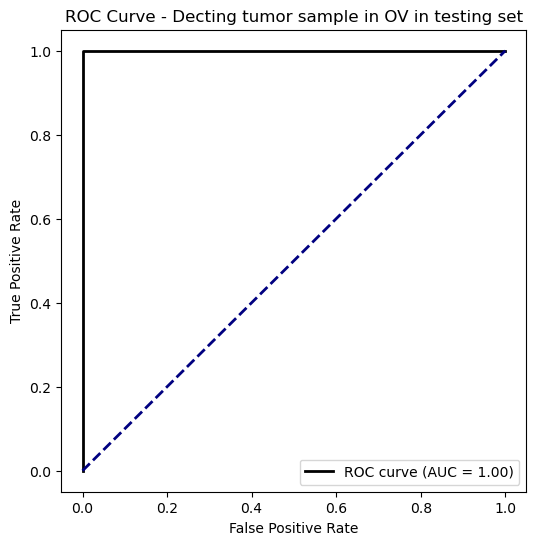

In [10]:

### Prediction
y_proba = rf.predict_proba(X_test)[:, 1]  # Probability of class 1 (Tumor)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = "black", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color = "navy", lw=2, linestyle= "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Decting tumor sample in {cancer_type} in testing set")
plt.legend(loc="lower right")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_ROC_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()


    idx_test     Sample Sample_Type  y_test  y_pred
0         94  01OV047_T           T       1   0.984
1         20  04OV057_T           T       1   0.968
2         88  04OV013_T           T       1   0.950
3         60  04OV021_T           T       1   0.894
4         80  17OV029_T           T       1   0.942
5         12  11OV010_N           N       0   0.194
6         69  01OV039_T           T       1   0.984
7         39  02OV006_T           T       1   0.990
8         78  01OV026_T           T       1   0.944
9         10  15OV001_N           N       0   0.114
10        77  11OV002_T           T       1   0.970
11        65  04OV031_T           T       1   0.984
12        40  26OV009_T           T       1   0.962
13        75  01OV041_T           T       1   0.960
14        87  14OV011_T           T       1   0.936
15        67  26OV013_T           T       1   0.992
16        70  04OV055_T           T       1   0.974
17        21  04OV028_T           T       1   0.974
18        33

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_28090/88673498.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)


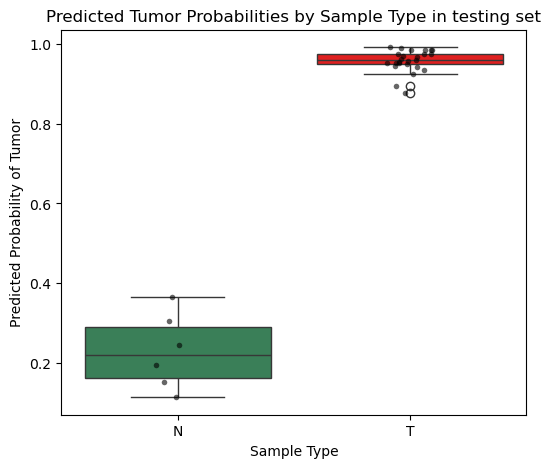

In [11]:

### Create performance DataFrame with Sample info and visualize the proba in testing set
performance = pd.DataFrame({
    "idx_test": idx_test,
    "Sample": samples[idx_test],   # sample names
    "Sample_Type": samples_type[idx_test],
    "y_test": y_test,
    "y_pred": y_proba
})

print(performance)

performance_sort = performance.sort_values("y_pred").reset_index(drop=True)

#pd.set_option("display.max_rows", None)
#print(performance_sort)

### Boxplot on the prediction score in testing set
custom_palette = {"N": "seagreen", "T": "red"}

plt.figure(figsize=(6,5))
sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)
sns.stripplot(data=performance, x="Sample_Type", y="y_pred", color="black", size=4, jitter=True, alpha=0.6)
plt.ylabel("Predicted Probability of Tumor")
plt.xlabel("Sample Type")
plt.title("Predicted Tumor Probabilities by Sample Type in testing set")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_Proba_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()

In [12]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
feature_importance_sort.head(5)

,ensembl_ids_clean,Gene,left_mean,right_mean,diff_mean,t_vals,p_vals,feature_importance
idx,,,,,,,,
ENSG00000173641.17,ENSG00000173641,HSPB7,22.741658820173413,24.94895644461816,-2.207298,-5.361671,1.371946e-04,0.017025
ENSG00000122707.12,ENSG00000122707,RECK,23.25448086590623,24.989525494008408,-1.735045,-10.872230,6.380265e-09,0.015286
ENSG00000177469.13,ENSG00000177469,CAVIN1,28.27753745561475,30.39415675537923,-2.116619,-9.597299,1.757904e-08,0.012266
ENSG00000141338.14,ENSG00000141338,ABCA8,19.96367590775356,22.36805840001696,-2.404382,-11.107280,9.923765e-09,0.012141
ENSG00000140945.17,ENSG00000140945,CDH13,24.711769099340607,26.973406952816013,-2.261638,-9.140625,1.600146e-07,0.010992


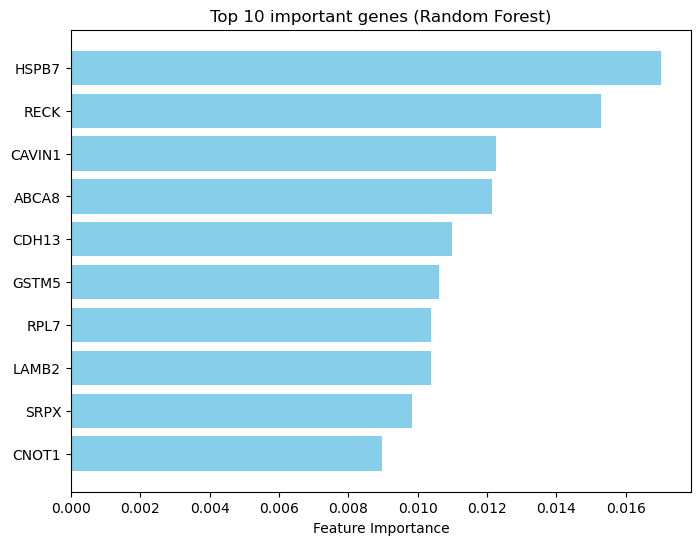

In [13]:
top_n = 10
plt.figure(figsize=(8,6))
plt.barh(
    feature_importance_sort['Gene'][:top_n][::-1],
    feature_importance_sort['feature_importance'][:top_n][::-1],
    color='skyblue'
)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} important genes (Random Forest)")
plt.show()


#### Step 3: Explore the features with biological input

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_28090/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


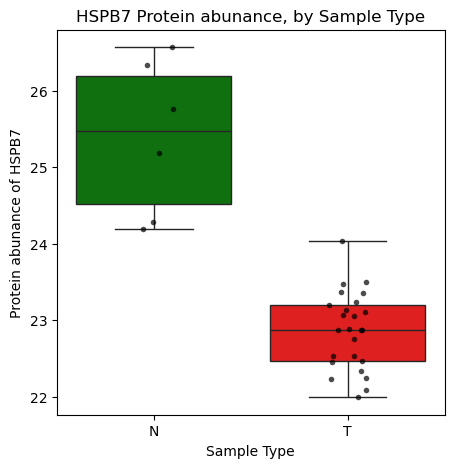

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_28090/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


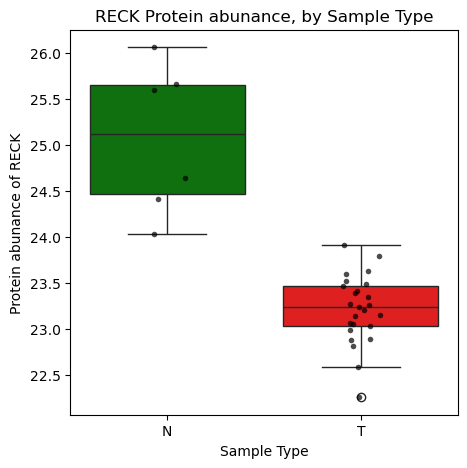

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_28090/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


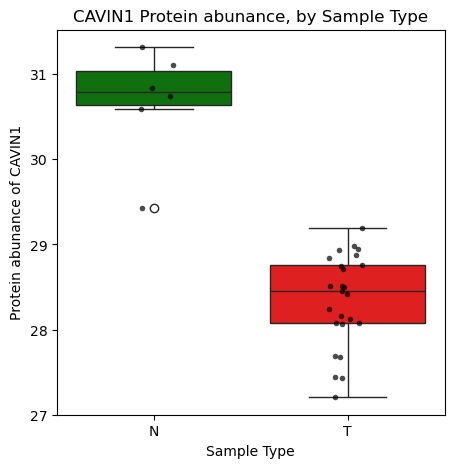

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_28090/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


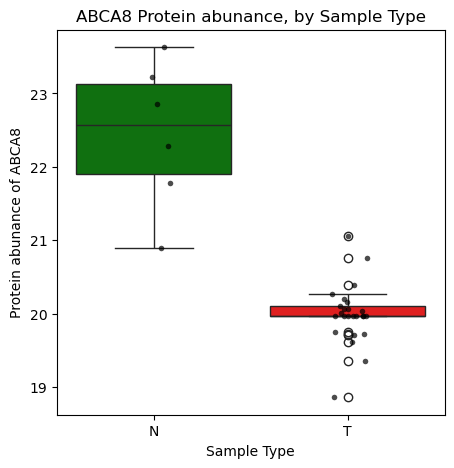

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_28090/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


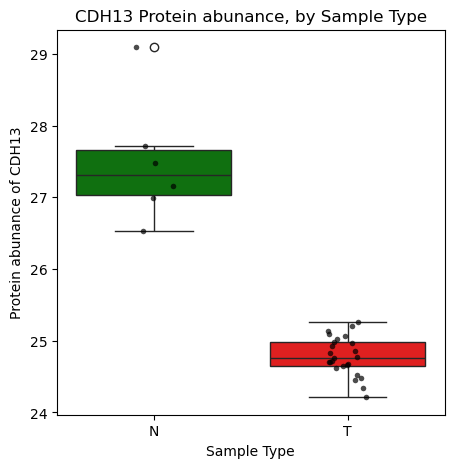

In [14]:
### Boxplot on important genes in testing set
selected_genes = feature_importance_sort.iloc[0:5, ].index.to_list()

df = pd.DataFrame(
    adata_test.X, 
    index=adata_test.obs.index,
    columns=adata_test.var.index  # or adata.var['Gene'] if you prefer gene symbols
).join(adata_test.obs)


for gene in selected_genes:
    
    plt.figure(figsize=(5,5))
    sns.boxplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        palette={"N": "green", "T": "red"}
    )
    sns.stripplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        color="black", 
        size=4, 
        jitter=True, 
        alpha=0.7
    )
    plt.ylabel(f"Protein abunance of {adata.var.loc[gene, 'Gene']}")
    plt.xlabel("Sample Type")
    plt.title(f"{adata.var.loc[gene, 'Gene']} Protein abunance, by Sample Type")
    plt.show()



In [15]:
# check if the NA is imputed
#adata[:, adata.var["Gene"] == "SCN7A" ].X

Total number of samples: 31


<Figure size 900x900 with 0 Axes>

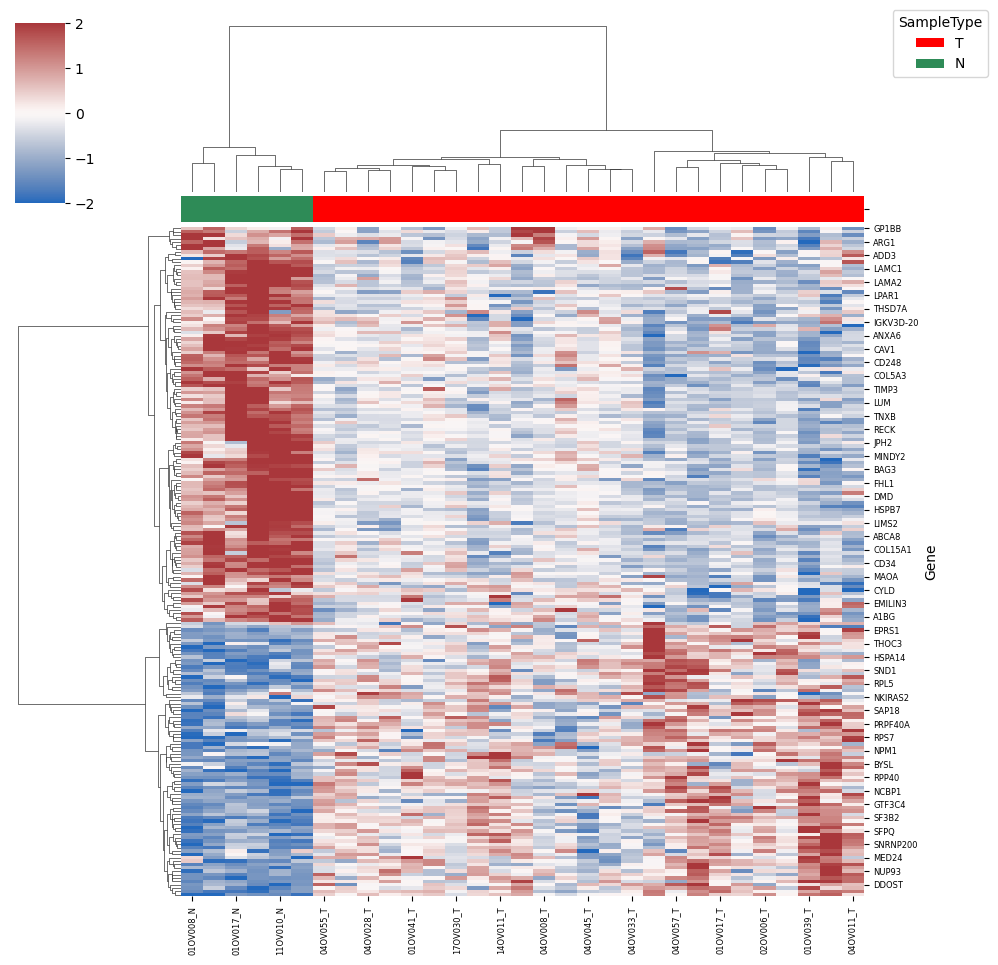

In [15]:

### Heatmap on top 200 important genes on testing set

selected_genes = feature_importance_sort.iloc[0:200, ].index.to_list()
adata_test_selected_genes = adata_test[:, selected_genes]

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(adata_test_selected_genes.X),
    columns=adata_test_selected_genes.var["Gene"],    # genes
    index=adata_test_selected_genes.obs.index   # samples
)
df_scaled_T = df_scaled.T
# Map disease status to colors
disease_status_col = "SampleType"
lut = {"T": "red", "N": "seagreen"}
dict_colors = adata_test_selected_genes.obs[disease_status_col].map(lut).to_dict()
col_colors = pd.Series(dict_colors)[df_scaled_T.columns]

print(f"Total number of samples: {len(col_colors)}")

# Cluster map
fig = plt.figure(figsize =(9,9))
g= sns.clustermap(
    df_scaled_T,
    col_colors=col_colors,
    cmap="vlag",
    method="ward",
    center=0,
    vmin=-2,
    vmax=2,
    xticklabels=True,
    yticklabels=True
)
# Option 2: Skip some labels (subsample)
yticks = g.ax_heatmap.get_yticks()              # tick positions
ylabels = [lab.get_text() for lab in g.ax_heatmap.get_yticklabels()]  # label texts

skip = 4  # show every 5th gene
g.ax_heatmap.set_yticks(yticks[::skip])
g.ax_heatmap.set_yticklabels(ylabels[::skip], fontsize=6, rotation=0)

# Option 2: Skip some labels (subsample)
xticks = g.ax_heatmap.get_xticks()              # tick positions
xlabels = [lab.get_text() for lab in g.ax_heatmap.get_xticklabels()]  # label texts

skip = 2  # show every 5th gene
g.ax_heatmap.set_xticks(xticks[::skip])
g.ax_heatmap.set_xticklabels(xlabels[::skip], fontsize=6, rotation=90)


# Legend
handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(
    handles,
    lut,
    title=disease_status_col,
    bbox_to_anchor=(1, 1),
    bbox_transform=plt.gcf().transFigure,
    loc="upper right"
)
plt.show()


In [16]:
print(np.isfinite(df_scaled_T.values).all()) 

True


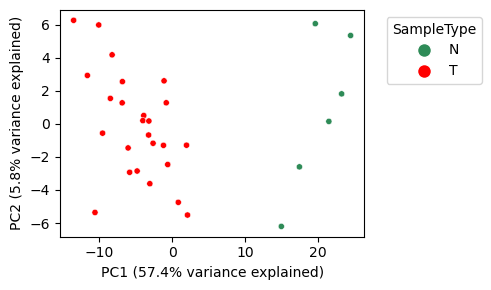

In [17]:

### PCA on top 200 important genes on testing set

scaler = StandardScaler()
df_scaled = scaler.fit_transform(adata_test_selected_genes.X)
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(
    data = pca_result[:, :2],
    columns= ['PC1', 'PC2'],
    index = adata_test_selected_genes.obs.index
).join(adata_test_selected_genes.obs)

var_explained = pca.explained_variance_ratio_ * 100

disease_status_col = "SampleType"

color_dict = {
    'T': 'red',      # Red
    'N': 'seagreen'   # Green
}
legend_order = ['N', 'T']

fig = plt.figure(figsize =(6,3))
sns.scatterplot(
    data = df_pca,
    x = 'PC1',
    y = 'PC2',
    hue = disease_status_col,
    s = 20,
    palette=color_dict
)

plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')

# Create handles and labels in the specific order
handles = []
labels = []
for category in legend_order:
    if category in color_dict:  # Make sure the category exists in your dictionary
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[category], markersize=10))
        labels.append(category)

# Create the legend with the ordered handles and labels
plt.legend(handles, labels, title=disease_status_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()



/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_28090/2067379197.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()


               Gene_set                       Term Overlap       P-value  \
0  MSigDB_Hallmark_2020             Myc Targets V1  16/200  1.035580e-16   
1  MSigDB_Hallmark_2020             Myc Targets V2    4/58  8.968993e-05   
2  MSigDB_Hallmark_2020  Unfolded Protein Response   5/113  9.587274e-05   
3  MSigDB_Hallmark_2020           mTORC1 Signaling   6/200  1.614644e-04   
4  MSigDB_Hallmark_2020                E2F Targets   6/200  1.614644e-04   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      2.278275e-15            0                     0   26.401338   
1      7.030668e-04            0                     0   19.110149   
2      7.030668e-04            0                     0   12.068104   
3      7.104434e-04            0                     0    8.134021   
4      7.104434e-04            0                     0    8.134021   

   Combined Score                                              Genes  
0      971.738205  SMARCC1;NPM1;SF3B3;NCBP1;CBX3;RP

<Axes: title={'center': 'UpRegulated 81 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

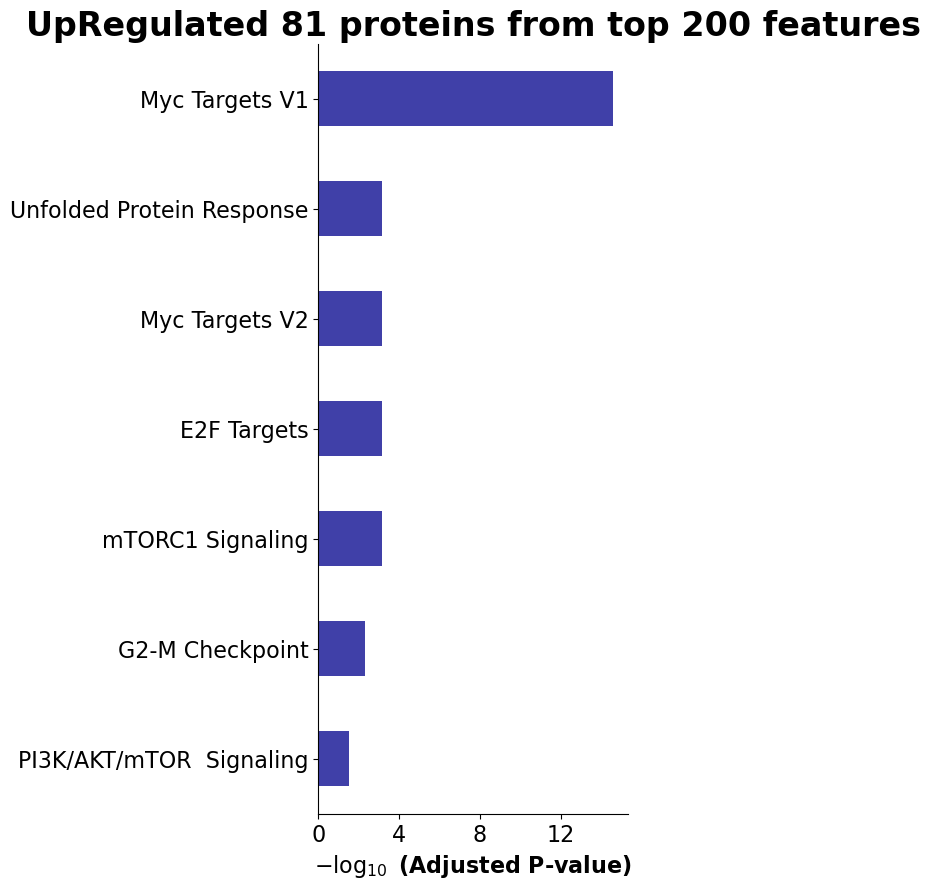

In [18]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 gene_sets=['MSigDB_Hallmark_2020'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'UpRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_28090/4001799050.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()


               Gene_set                               Term Overlap  \
0  MSigDB_Hallmark_2020                         Myogenesis  13/200   
1  MSigDB_Hallmark_2020  Epithelial Mesenchymal Transition   8/200   
2  MSigDB_Hallmark_2020                       Adipogenesis   7/200   
3  MSigDB_Hallmark_2020                          Apoptosis   6/161   
4  MSigDB_Hallmark_2020                    Apical Junction   6/200   

        P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  \
0  2.087009e-10      6.469727e-09            0                     0   
1  2.640839e-05      4.093300e-04            0                     0   
2  1.960408e-04      2.025755e-03            0                     0   
3  4.066430e-04      3.151483e-03            0                     0   
4  1.262475e-03      6.522789e-03            0                     0   

   Odds Ratio  Combined Score  \
0   12.916053      287.900358   
1    7.390766       77.912188   
2    6.375648       54.430102   
3    6.757408 

<Axes: title={'center': 'DownRegulated 119 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

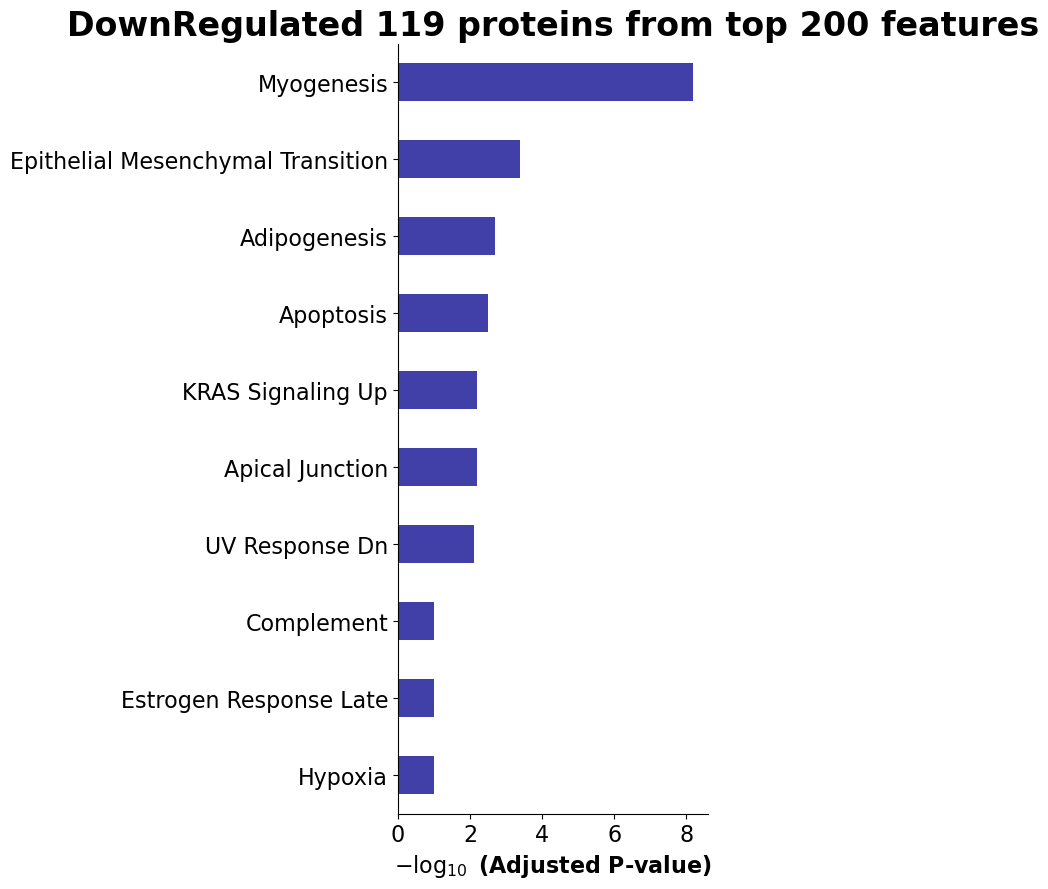

In [19]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 gene_sets=['MSigDB_Hallmark_2020'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'DownRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')